# <font color="red"> Taller: Red Neuronal Artificial (ANN) — Clasificación Multiclase </font>

**Universidad Andrés Bello — Ciencia de Datos**

---

**Objetivo:** Entrenar una red neuronal artificial para clasificar clientes según su puntaje de crédito en tres categorías:  
- `0` → Poor (Malo)  
- `1` → Standard (Regular)  
- `2` → Good (Bueno)

**Dataset:** Credit Score Classification — Kaggle  
**URL:** `https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx`

---
## <font color="blue"> 1. Clasificación Multiclase con Redes Neuronales </font>

La **clasificación multiclase** (o *multi-class classification*) es un problema en el que cada instancia debe asignarse a una de **tres o más clases mutuamente excluyentes**.

A diferencia de la clasificación binaria (0 vs 1), en la clasificación multiclase la capa de salida debe:
- Tener **N neuronas** (una por clase)
- Usar la función de activación **Softmax**, que convierte las salidas en probabilidades que suman 1
- Usar la función de pérdida **`sparse_categorical_crossentropy`** (cuando las etiquetas son enteros) o **`categorical_crossentropy`** (cuando las etiquetas están en formato one-hot)

### Comparación de configuraciones de salida

| Tipo de problema | Neuronas en capa de salida | Activación | Función de pérdida |
|---|---|---|---|
| Regresión | 1 | Lineal | MSE / MAE |
| Clasificación binaria | 1 | Sigmoid | Binary Crossentropy |
| Clasificación multiclase | N (nº de clases) | Softmax | Sparse / Categorical Crossentropy |

---
## <font color="blue"> 2. Función de Activación Softmax </font>

La función **Softmax** toma un vector de valores reales $\mathbf{z} = [z_1, z_2, \ldots, z_K]$ y los transforma en probabilidades:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Propiedades:**
- Cada salida está en el rango $[0, 1]$
- La suma de todas las salidas es siempre $1$
- La neurona con mayor valor representa la clase predicha

**Ejemplo:** Para 3 clases (Poor, Standard, Good):  
`softmax([2.0, 1.0, 0.5]) → [0.659, 0.242, 0.099]`  
→ El modelo predice clase 0 (Poor) con 65.9% de probabilidad.

### Función de Pérdida: Sparse Categorical Crossentropy

$$\mathcal{L} = -\sum_{i=1}^{N} \log(\hat{p}_{y_i})$$

Donde $\hat{p}_{y_i}$ es la probabilidad predicha para la clase verdadera $y_i$.  
Se usa **`sparse_categorical_crossentropy`** cuando las etiquetas son enteros (0, 1, 2, ...) — sin necesidad de one-hot encoding.

---
## <font color="blue"> 3. Arquitectura de la Red Neuronal </font>

Para este problema utilizaremos una red densa (*fully connected / dense neural network*) con la siguiente arquitectura:

```
Input (n_features)  →  Dense(128, relu)  →  BatchNorm  →  Dropout(0.3)
                    →  Dense(64,  relu)  →  BatchNorm  →  Dropout(0.2)
                    →  Dense(32,  relu)
                    →  Dense(3,   softmax)   ← capa de salida
```

### Componentes clave

| Componente | Función |
|---|---|
| **Dense(n, relu)** | Capa totalmente conectada con activación ReLU |
| **BatchNormalization** | Normaliza las activaciones en cada mini-batch; estabiliza y acelera el entrenamiento |
| **Dropout(p)** | Apaga aleatoriamente p% de neuronas por epoch; reduce el sobreajuste |
| **Dense(3, softmax)** | Capa de salida: 3 neuronas con probabilidades para cada clase de crédito |

---
## <font color="blue"> 4. Regularización y Early Stopping </font>

El **sobreajuste** (*overfitting*) ocurre cuando el modelo memoriza los datos de entrenamiento pero no generaliza bien a datos nuevos. Las principales técnicas para combatirlo son:

- **Dropout:** En cada paso de entrenamiento, apaga aleatoriamente una fracción de neuronas, forzando a la red a aprender representaciones más robustas.
- **Batch Normalization:** Normaliza las salidas de cada capa, actuando también como regulador implícito.
- **Early Stopping:** Detiene el entrenamiento cuando la pérdida en validación deja de mejorar.

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                # espera 10 epochs sin mejora
    restore_best_weights=True   # restaura los pesos del mejor epoch
)
```

### Parámetros del entrenamiento

| Parámetro | Descripción | Valor típico |
|---|---|---|
| `epochs` | Número máximo de pasadas completas por los datos | 100–200 |
| `batch_size` | Número de muestras por actualización de pesos | 32–256 |
| `validation_split` | Fracción de datos de entrenamiento usada para validación | 0.2 |
| `patience` (EarlyStopping) | Epochs de espera sin mejora antes de detener | 5–15 |

---
## <font color="blue"> 5. Reducción de Dimensionalidad: PCA </font>

El **Análisis de Componentes Principales** (PCA) es una técnica de reducción de dimensionalidad que:
1. Transforma las features originales en nuevas variables no correlacionadas llamadas **componentes principales**
2. Las ordena por varianza explicada (de mayor a menor)
3. Permite retener un porcentaje de la varianza total con menos dimensiones

$$\text{Varianza explicada acumulada} = \sum_{i=1}^{k} \lambda_i \bigg/ \sum_{j=1}^{p} \lambda_j$$

Al usar `PCA(n_components=0.95)` se retienen automáticamente los componentes necesarios para explicar el **95% de la varianza** de los datos.

**Ventajas en este contexto:**
- Reduce el ruido en los datos
- Elimina multicolinealidad entre features
- Puede mejorar la generalización del modelo

> **Nota importante:** El PCA se ajusta (`fit`) **solo** con los datos de entrenamiento, y luego se aplica (`transform`) a validación y test para evitar *data leakage*.

---
# <font color="red"> PRÁCTICA </font>

## <font color="blue"> 6. Importación de Librerías </font>

In [6]:

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# Manejo de datos
import pandas as pd
import numpy as np
# Deep Learning
import tensorflow as tf
# Serialización de objetos
import joblib
import os

print(f'TensorFlow versión: {tf.__version__}')
print(f'GPUs disponibles: {tf.config.list_physical_devices("GPU")}')

TensorFlow versión: 2.21.0
GPUs disponibles: []


## <font color="blue"> 7. Carga y Exploración de Datos (EDA) </font>

In [8]:
# Tipos de datos y valores nulos
print('Tipos de datos y valores nulos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())

Tipos de datos y valores nulos:
Customer_ID                     str
Name                            str
Age                         float64
SSN                             str
Occupation                      str
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                    str
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour               str
Monthly_Balance             float64
Credit_Score                  int64
dtype: object

Valores nulos por

Distribución de Credit_Score:
Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


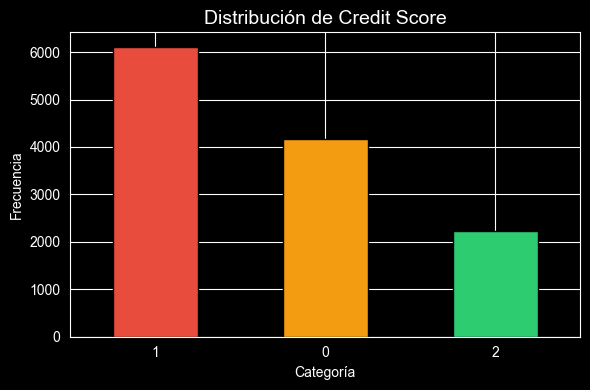

In [9]:
# Distribución de la variable objetivo
print('Distribución de Credit_Score:')
print(df['Credit_Score'].value_counts())

plt.figure(figsize=(6, 4))
df['Credit_Score'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
plt.title('Distribución de Credit Score', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Estadísticas descriptivas de columnas numéricas (sample)
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Age,12500.0,33.311294,10.760177,14.000000,24.415179,33.000000,41.750000,56.000000
Annual_Income,12500.0,50505.123449,38300.762656,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000
Monthly_Inhand_Salary,12500.0,4198.468568,3187.142979,303.645417,1625.744479,3097.016667,5961.664375,15204.633333
Num_Bank_Accounts,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Credit_Card,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Interest_Rate,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_of_Delayed_Payment,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Changed_Credit_Limit,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000


## <font color="blue"> 8. Preprocesamiento de Datos </font>

El dataset contiene varios tipos de problemas comunes que deben resolverse antes del modelado:
- Columnas irrelevantes para la predicción (`Customer_ID`, `Name`, `SSN`)
- Variables categóricas que deben codificarse numéricamente (`Credit_Mix`, `Payment_of_Min_Amount`, `Occupation`, `Payment_Behaviour`)
- Campo `Type_of_Loan` multi-valor que debe simplificarse contando el número de tipos

> **Nota sobre este dataset:** `Credit_History_Age` ya viene como número decimal (años fraccionarios) y `Credit_Score` ya está codificado como entero (0=Poor, 1=Standard, 2=Good), por lo que no requieren transformaciones adicionales.

In [11]:
# ── Paso 1: Eliminar columnas irrelevantes ──────────────────────────────────
df = df.drop(columns=['Customer_ID', 'Name', 'SSN'], errors='ignore')
print(f'Columnas tras eliminar irrelevantes: {df.shape[1]}')

Columnas tras eliminar irrelevantes: 23


In [12]:
# ── Paso 2: Limpiar columnas numéricas con trailing '_' ─────────────────────
# Algunas columnas tienen valores como '1200.5_' o '25_' → limpiar y convertir a float
numeric_cols_to_clean = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Outstanding_Debt',
    'Amount_invested_monthly', 'Monthly_Balance'
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        # 1. Convertir a string
        # 2. Reemplazar '_' por vacío
        # 3. Convertir a numérico (coerce convierte errores en NaN)
        df[col] = df[col].astype(str).str.replace('_', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # 4. Llenar NaNs con la mediana para evitar perder demasiadas filas en el dropna
        df[col] = df[col].fillna(df[col].median())

print('Limpieza de columnas numéricas completada.')

Limpieza de columnas numéricas completada.


In [13]:
# ── Paso 3: Renombrar Credit_History_Age ───────────────────────────────────
# En este dataset el campo ya viene como número decimal (años fraccionarios).
# Lo renombramos a Credit_History_Age_Months para mantener consistencia con
# el pipeline de la app de despliegue.
df = df.rename(columns={'Credit_History_Age': 'Credit_History_Age_Months'})
print(f'Credit_History_Age_Months — primeros valores: {df["Credit_History_Age_Months"].head(5).tolist()}')
print(f'Tipo de dato: {df["Credit_History_Age_Months"].dtype}')

Credit_History_Age_Months — primeros valores: [10.45833333333333, 30.71428571428572, 15.57142857142857, 15.54166666666667, 17.53571428571428]
Tipo de dato: float64


In [14]:
# Paso 4: Codificar Credit_Mix (Bad=0, Standard=1, Good=2)
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map)
print('Credit_Mix unicos:', df['Credit_Mix'].unique())
print('Credit_Mix nulos:', df['Credit_Mix'].isna().sum())


Credit_Mix unicos: [0 1 2]
Credit_Mix nulos: 0


In [15]:
# Paso 5: Codificar Payment_of_Min_Amount (Yes=1, No=0, NM=0)
poma_map = {'Yes': 1, 'No': 0, 'NM': 0}
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map(poma_map)
print('Payment_of_Min_Amount unicos:', df['Payment_of_Min_Amount'].unique())
print('Payment_of_Min_Amount nulos:', df['Payment_of_Min_Amount'].isna().sum())


Payment_of_Min_Amount unicos: [1 0]
Payment_of_Min_Amount nulos: 0


In [16]:
# Paso 6: Contar tipos de prestamos desde Type_of_Loan
def count_loan_types(loan_str):
    """Cuenta cuantos tipos de prestamo distintos tiene el cliente."""
    if pd.isna(loan_str):
        return 0
    return len([x.strip() for x in str(loan_str).split(',') if x.strip()])

df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_loan_types)
df.drop(columns=['Type_of_Loan'], inplace=True)
print('Num_Loan_Types - distribucion:')
print(df['Num_Loan_Types'].value_counts().sort_index())


Num_Loan_Types - distribucion:
Num_Loan_Types
0    1426
1    1391
2    1964
3    1969
4    1932
5     941
6    1018
7     960
8     417
9     482
Name: count, dtype: int64


In [17]:
# Paso 7: LabelEncoder para Occupation y Payment_Behaviour
from sklearn.preprocessing import LabelEncoder

le_occupation = LabelEncoder()
le_payment_behaviour = LabelEncoder()

df['Occupation'] = le_occupation.fit_transform(df['Occupation'].astype(str))
df['Payment_Behaviour'] = le_payment_behaviour.fit_transform(df['Payment_Behaviour'].astype(str))

print('Clases de Occupation:', le_occupation.classes_)
print('Clases de Payment_Behaviour:', le_payment_behaviour.classes_)


Clases de Occupation: ['Accountant' 'Architect' 'Developer' 'Doctor' 'Engineer' 'Entrepreneur'
 'Journalist' 'Lawyer' 'Manager' 'Mechanic' 'Media_Manager' 'Musician'
 'Scientist' 'Teacher' 'Writer']
Clases de Payment_Behaviour: ['High_spent_Large_value_payments' 'High_spent_Medium_value_payments'
 'High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments']


In [18]:
# Paso 8: Verificar Credit_Score (ya es entero 0/1/2, no requiere mapeo)
print('Distribucion Credit_Score:')
print(df['Credit_Score'].value_counts().sort_index())
print('Dtype:', df['Credit_Score'].dtype)
print('Valores unicos:', sorted(df['Credit_Score'].unique()))


Distribucion Credit_Score:
Credit_Score
0    4162
1    6111
2    2227
Name: count, dtype: int64
Dtype: int64
Valores unicos: [np.int64(0), np.int64(1), np.int64(2)]


In [19]:
# Paso 9: Eliminar filas con valores nulos restantes
print('Filas antes de dropna:', len(df))
df.dropna(inplace=True)
print('Filas despues de dropna:', len(df))
print('Nulos restantes:', df.isna().sum().sum())


Filas antes de dropna: 12500
Filas despues de dropna: 12500
Nulos restantes: 0


In [20]:
# Paso 10: Definir columnas de features y construir X e y
FEATURE_COLUMNS = [
    'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
    'Credit_History_Age_Months', 'Num_Loan_Types'
]

X = df[FEATURE_COLUMNS].values
y = df['Credit_Score'].values

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)
print('Clases en y:', sorted(set(y)))


Shape de X: (12500, 22)
Shape de y: (12500,)
Clases en y: [np.int64(0), np.int64(1), np.int64(2)]


---
## <font color='blue'> 9. Division de Datos: Entrenamiento, Validacion y Prueba </font>

Dividimos el dataset en tres conjuntos:

| Conjunto | Proporcion | Uso |
|----------|-----------|-----|
| **Entrenamiento** | 70% | Ajustar los pesos de la red |
| **Validacion** | 15% | Monitorear el entrenamiento y aplicar Early Stopping |
| **Prueba** | 15% | Evaluacion final imparcial del modelo |

Se usa `stratify=y` para garantizar que cada particion tenga la misma proporcion de clases.


In [21]:
from sklearn.model_selection import train_test_split

# Primera division: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda division: 50% de temp => 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validacion:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)')


Entrenamiento: 8750 muestras (70.0%)
Validacion:    1875 muestras (15.0%)
Prueba:        1875 muestras (15.0%)


---
## <font color='blue'> 10. Normalizacion con StandardScaler </font>

Las redes neuronales son sensibles a la escala de los datos. El **StandardScaler** transforma
cada feature para que tenga **media = 0** y **desviacion estandar = 1**:

$$z = \frac{x - \mu}{\sigma}$$

> **Importante:** el scaler se ajusta **solo** con los datos de entrenamiento y se aplica
> a validacion y prueba para evitar *data leakage*.


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Media (primeras 5 features):', X_train_sc.mean(axis=0)[:5].round(4))
print('Std  (primeras 5 features):', X_train_sc.std(axis=0)[:5].round(4))


Media (primeras 5 features): [ 0. -0.  0. -0.  0.]
Std  (primeras 5 features): [1. 1. 1. 1. 1.]


---
## <font color='blue'> 11. Reduccion de Dimensionalidad con PCA </font>

El **Analisis de Componentes Principales (PCA)** proyecta los datos en un espacio de menor
dimension preservando la mayor varianza posible.

Usamos `n_components=0.95` para retener automaticamente el numero de componentes que
explican el **95%** de la varianza total.


Componentes seleccionados (95% varianza): 15
Varianza explicada total: 95.93%


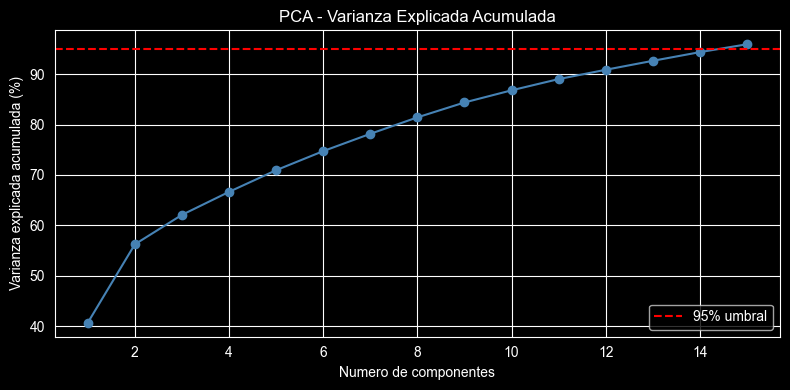

Dimension original: 22  ->  Dimension reducida: 15


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

n_comp = pca.n_components_
print(f'Componentes seleccionados (95% varianza): {n_comp}')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.2f}%')

# Grafico de varianza acumulada
cumvar = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_comp+1), cumvar * 100, marker='o', color='steelblue')
plt.axhline(95, color='red', linestyle='--', label='95% umbral')
plt.xlabel('Numero de componentes')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('PCA - Varianza Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Dimension original: {X_train_sc.shape[1]}  ->  Dimension reducida: {X_train_pca.shape[1]}')


---
## <font color='blue'> 12. Construccion de la Red Neuronal </font>

Arquitectura:

| Capa | Neuronas | Activacion | Descripcion |
|------|----------|-----------|-------------|
| Densa 1 | 128 | ReLU | Primera capa oculta |
| Dropout 1 | — | — | Regularizacion (20%) |
| Densa 2 | 64 | ReLU | Segunda capa oculta |
| Dropout 2 | — | — | Regularizacion (20%) |
| Densa 3 | 32 | ReLU | Tercera capa oculta |
| Salida | 3 | Softmax | Probabilidad por clase |

La funcion de perdida es `sparse_categorical_crossentropy` (etiquetas enteras sin one-hot encoding).


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

tf.random.set_seed(42)

n_input = X_train_pca.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(n_input,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()


C:\Users\daelr\Desarrollo\UNAB\ANN Multiclass\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 384 (1.50 KB)

---
## <font color='blue'> 13. Compilacion y Entrenamiento </font>

Configuracion del entrenamiento:

- **Optimizador**: Adam (tasa de aprendizaje adaptativa)
- **Perdida**: `sparse_categorical_crossentropy` (multiclase con etiquetas enteras)
- **Metrica**: `accuracy`
- **Early Stopping**: detiene el entrenamiento si `val_loss` no mejora en 10 epocas consecutivas
  y restaura los mejores pesos automaticamente.


In [25]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_pca, y_train,
    validation_data=(X_val_pca, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6030 - loss: 0.9076 - val_accuracy: 0.6635 - val_loss: 0.7655
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6825 - loss: 0.7208 - val_accuracy: 0.6907 - val_loss: 0.6823
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6997 - loss: 0.6898 - val_accuracy: 0.7104 - val_loss: 0.6645
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7010 - loss: 0.6789 - val_accuracy: 0.7184 - val_loss: 0.6600
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7103 - loss: 0.6602 - val_accuracy: 0.7200 - val_loss: 0.6505
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7128 - loss: 0.6540 - val_accuracy: 0.7291 - val_loss: 0.6438
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7159 - loss: 0.6442 - val_accuracy: 0.7269 - val_loss: 0.6428
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7190 - loss: 0.6385 - val_accu

---
## <font color='blue'> 14. Curvas de Aprendizaje </font>

Las curvas de aprendizaje muestran como evolucionan la **perdida** y la **exactitud** durante
el entrenamiento. Nos permiten detectar:

- **Underfitting**: curvas que no convergen o con alta perdida en entrenamiento
- **Overfitting**: gran brecha entre la curva de entrenamiento y validacion
- **Buen ajuste**: curvas que convergen y se mantienen cercanas


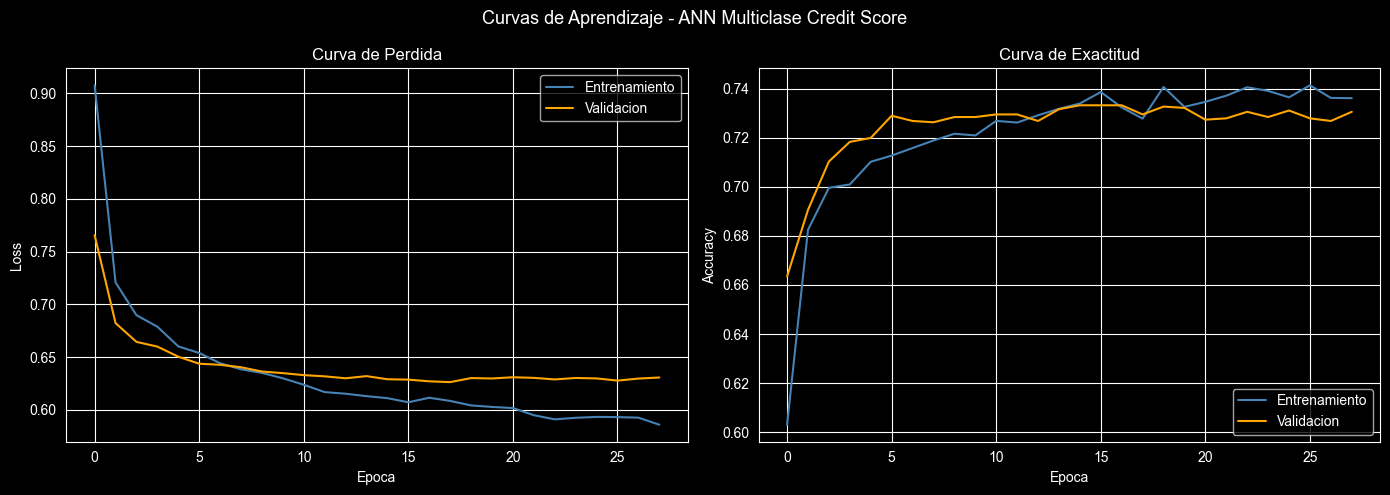

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perdida
axes[0].plot(history.history['loss'], label='Entrenamiento', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validacion', color='orange')
axes[0].set_title('Curva de Perdida')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Exactitud
axes[1].plot(history.history['accuracy'], label='Entrenamiento', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validacion', color='orange')
axes[1].set_title('Curva de Exactitud')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de Aprendizaje - ANN Multiclase Credit Score', fontsize=13)
plt.tight_layout()
plt.show()


---
## <font color='blue'> 15. Evaluacion en el Conjunto de Prueba </font>

Evaluamos el modelo con datos que **nunca vio** durante el entrenamiento ni la validacion.

Metricas reportadas:
- **Accuracy**: porcentaje de predicciones correctas
- **Reporte de clasificacion**: precision, recall y F1-score por clase
- **Matriz de confusion**: visualizacion de errores por clase


Loss en prueba:     0.6031
Accuracy en prueba: 74.35%
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Reporte de Clasificacion:
              precision    recall  f1-score   support

    Poor (0)       0.81      0.68      0.74       625
Standard (1)       0.76      0.81      0.78       916
    Good (2)       0.61      0.67      0.64       334

    accuracy                           0.74      1875
   macro avg       0.73      0.72      0.72      1875
weighted avg       0.75      0.74      0.74      1875



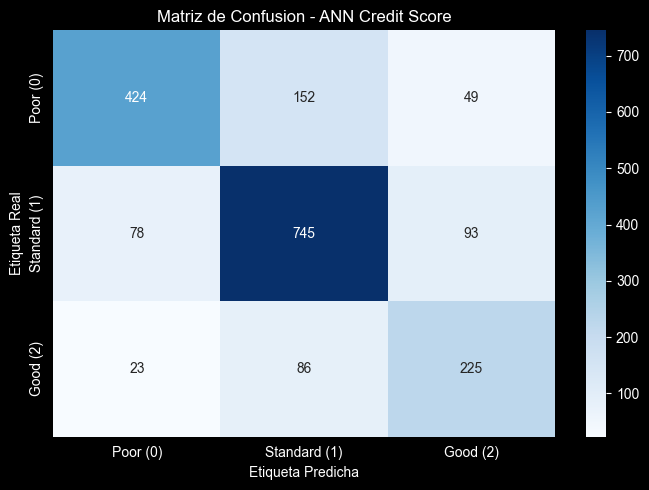

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluacion general
test_loss, test_acc = model.evaluate(X_test_pca, y_test, verbose=0)
print(f'Loss en prueba:     {test_loss:.4f}')
print(f'Accuracy en prueba: {test_acc*100:.2f}%')

# Predicciones
y_pred_proba = model.predict(X_test_pca)
y_pred = y_pred_proba.argmax(axis=1)

# Reporte de clasificacion
class_names = ['Poor (0)', 'Standard (1)', 'Good (2)']
print('\nReporte de Clasificacion:')
print(classification_report(y_test, y_pred, target_names=class_names))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - ANN Credit Score')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()


In [7]:
# Cargar el dataset desde GitHub
URL = 'https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx'
df = pd.read_excel(URL)

print(f'Dimensiones del dataset: {df.shape}')
df.head(3)

Dimensiones del dataset: (12500, 26)


,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
